# Check parquet integrity

The following notebook explores the metadata parquet created by build_metadata_table.py. Much of the following EDA relates to confirming joining logic and ensuring results are as expected. Finally, a cleaned dataframe is created. Also note that the following performs site/field-level embeddings, not well-level embeddings.

In [1]:
import pandas as pd
import numpy as np

# Load data
PATH = "../data/processed/master_metadata.parquet"
df = pd.read_parquet(PATH)
df = df[df["plate"] != "BR00116992"] # TODO change

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (1535, 44)

Columns:
 ['plate', 'well', 'url_origdna', 'url_origlowzbf', 'url_orighighzbf', 'url_origbrightfield', 'url_origmito', 'url_origagp', 'url_origer', 'url_origrna', 'site', 'metadata_abspositionz', 'metadata_abstime', 'metadata_binningx', 'metadata_binningy', 'metadata_channelid', 'metadata_channelname', 'metadata_col', 'metadata_exposuretime', 'metadata_fieldid', 'metadata_imageresolutionx', 'metadata_imageresolutiony', 'metadata_imagesizex', 'metadata_imagesizey', 'metadata_mainemissionwavelength', 'metadata_mainexcitationwavelength', 'metadata_maxintensity', 'metadata_objectivemagnification', 'metadata_objectivena', 'metadata_planeid', 'metadata_positionx', 'metadata_positiony', 'metadata_positionz', 'metadata_row', 'broad_sample', 'solvent', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'image_paths']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1535 entries, 0 to 1801
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   plate                              1535 non-null   object 
 1   well                               1535 non-null   object 
 2   url_origdna                        1535 non-null   object 
 3   url_origlowzbf                     1535 non-null   object 
 4   url_orighighzbf                    1535 non-null   object 
 5   url_origbrightfield                1535 non-null   object 
 6   url_origmito                       1535 non-null   object 
 7   url_origagp                        1535 non-null   object 
 8   url_origer                         1535 non-null   object 
 9   url_origrna                        1535 non-null   object 
 10  site                               1535 non-null   int64  
 11  metadata_abspositionz              1535 non-null   float64
 1

In [3]:
df.head(20)

,plate,well,url_origdna,url_origlowzbf,url_orighighzbf,url_origbrightfield,url_origmito,url_origagp,url_origer,url_origrna,...,broad_sample,solvent,InChIKey,pert_iname,pubchem_cid,gene,pert_type,control_type,smiles,image_paths
0,BR00116991,A01,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[/scratch/creighton.jo/cellpainting/data/raw/i...
1,BR00116991,A02,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,unknown,DMSO,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,DMSO,679.0,unknown,control,negcon,CS(=O)C,[/scratch/creighton.jo/cellpainting/data/raw/i...
2,BR00116991,A03,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,BRD-A22032524-074-09-9,DMSO,HTIQEAQVCYTUBX-UHFFFAOYSA-N,amlodipine,2162.0,CACNA2D3,trt,unknown,CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OC,[/scratch/creighton.jo/cellpainting/data/raw/i...
3,BR00116991,A04,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,BRD-A01078468-001-14-8,DMSO,PBBGSZCBWVPOOL-UHFFFAOYSA-N,hexestrol,3606.0,AKR1C1,trt,unknown,CCC(C(CC)c1ccc(O)cc1)c1ccc(O)cc1,[/scratch/creighton.jo/cellpainting/data/raw/i...
4,BR00116991,A05,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,BRD-K48278478-001-01-2,DMSO,LOUPRKONTZGTKE-AFHBHXEDSA-N,quinine,94175.0,KCNN4,trt,unknown,COc1ccc2nccc([C@@H](O)[C@H]3C[C@@H]4CC[N@]3C[C...,[/scratch/creighton.jo/cellpainting/data/raw/i...
5,BR00116991,A06,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,...,BRD-K36574127-001-01-3,DMSO,NYNZQNWKBKUAII-KBXCAEBGSA-N,LOXO-101,46188928.0,NTRK1,trt,unknown,O[C@H]1CCN(C1)C(=O)Nc1cnn2ccc(nc12)N1CCC[C@@H]...,[/scratch/creighton.jo/cellpainting/data/raw/i...
6,BR00116991,A07,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s..

In [4]:
# Check missing values
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(20))

pubchem_cid                          0.028664
plate                                0.000000
metadata_positionz                   0.000000
metadata_mainemissionwavelength      0.000000
metadata_mainexcitationwavelength    0.000000
metadata_maxintensity                0.000000
metadata_objectivemagnification      0.000000
metadata_objectivena                 0.000000
metadata_planeid                     0.000000
metadata_positionx                   0.000000
metadata_positiony                   0.000000
metadata_row                         0.000000
well                                 0.000000
broad_sample                         0.000000
solvent                              0.000000
InChIKey                             0.000000
pert_iname                           0.000000
gene                                 0.000000
pert_type                            0.000000
control_type                         0.000000
dtype: float64


Note - image missingness due to only downloading subset of rows from plate

In [5]:
# Show treatment counts
if "broad_sample" in df.columns:
    print("\nunique compounds:", df["broad_sample"].nunique())


unique compounds: 307


In [6]:
# Check unique sites per well
if "site" in df.columns:
    print(df.groupby("well")["site"].nunique().describe())

count    384.000000
mean       1.010417
std        0.101662
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: site, dtype: float64


In [7]:
# Confirm no missing plates/wells
assert df["plate"].notna().all(), "Missing plate values!"
assert df["well"].notna().all(), "Missing well values!"

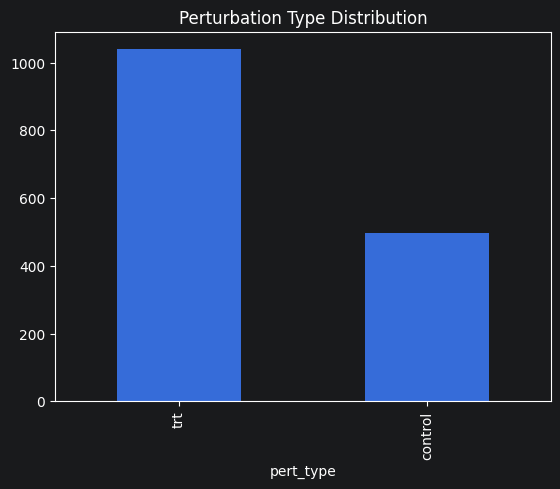

In [8]:
# Show perturbation type distribution
import matplotlib.pyplot as plt

df["pert_type"].value_counts().plot(kind="bar")
plt.title("Perturbation Type Distribution")
plt.show()

# EDA of parquet

In [9]:
# Descriptive stats
print("Unique plates:", df["plate"].nunique())
print("Unique wells:", df["well"].nunique())
print("Unique sites:", df["site"].nunique())
print("\nSites per well:")
print(df.groupby(["plate", "well"])["site"].nunique().describe())

Unique plates: 4
Unique wells: 384
Unique sites: 3

Sites per well:
count    1535.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: site, dtype: float64


In [10]:
# Print gene counts
gene_counts = (
    df.groupby("gene")
    .size()
    .sort_values(ascending=False)
)

print(gene_counts.head(20))

print("\nUnique genes:", df["gene"].nunique())
print("Median rows per gene:", gene_counts.median())

gene
unknown    256
HTR2C        8
MAPK8        8
MET          8
MME          8
MMP2         8
NAMPT        8
NTRK1        8
OPRL1        8
OPRM1        8
P2RY12       8
P3H1         8
PAK1         8
PAK4         8
PARP3        8
PDE3A        8
PDE4D        8
PDE7A        8
PDPK1        8
MAPK14       8
dtype: int64

Unique genes: 161
Median rows per gene: 8.0


In [11]:
# Print controls
print(df["control_type"].value_counts(dropna=False))
print("\nTreatment vs controls:")
print(df["pert_type"].value_counts(dropna=False))

control_type
unknown           1039
negcon             256
poscon_diverse     112
poscon_cp          104
poscon_orf          24
Name: count, dtype: int64

Treatment vs controls:
pert_type
trt        1039
control     496
Name: count, dtype: int64


In [12]:
# Show rows missing images
print("Rows with empty image lists:", (df["image_paths"].apply(len) == 0).sum())

Rows with empty image lists: 0


In [13]:
# Confirm consistent image sizes
cols = ["metadata_imagesizex", "metadata_imagesizey"]
for c in cols:
    if c in df.columns:
        print(c)
        print(df[c].value_counts())

metadata_imagesizex
metadata_imagesizex
1080    1535
Name: count, dtype: int64
metadata_imagesizey
metadata_imagesizey
1080    1535
Name: count, dtype: int64


In [14]:
# Show duplicate biological-image rows
dup_mask = df.duplicated(["plate", "well", "site"], keep=False)
print("Total duplicate rows:", dup_mask.sum())
if dup_mask.any():
    print("\nExample duplicates:")
    print(df[dup_mask].sort_values(["plate", "well", "site"]).head(20))

Total duplicate rows: 0


In [15]:
# Show sample image paths
sample = df[df["image_paths"].notna()].sample(5)

for _, row in sample.iterrows():
    print("\nWELL:", row["well"])
    print("SITE:", row["site"])
    print("IMAGE PATHS:")
    print(row["image_paths"])


WELL: J15
SITE: 1
IMAGE PATHS:
['/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch1sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch2sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch3sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch4sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch5sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch6sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch7sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f01p01-ch8sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f02p01-ch1sk1fk1fl1.tiff'
 '/scratch/creighton.jo/cellpainting/data/raw/images/BR00116995/r10c15f02p01-ch2sk1fk1fl1.tiff'
 '/scrat

# Preprocessing

In [16]:
keep_cols = [
    "image_paths",
    "plate",
    "well",
    "site",
    "broad_sample",
    "pert_iname",
    "pert_type",
    "control_type",
    "gene",
    "smiles",
    "InChIKey",
]
clean_df = df[keep_cols].copy()
clean_df.head(20)

,image_paths,plate,well,site,broad_sample,pert_iname,pert_type,control_type,gene,smiles,InChIKey
0,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
1,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A02,1,unknown,DMSO,control,negcon,unknown,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
2,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A03,1,BRD-A22032524-074-09-9,amlodipine,trt,unknown,CACNA2D3,CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OC,HTIQEAQVCYTUBX-UHFFFAOYSA-N
3,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A04,1,BRD-A01078468-001-14-8,hexestrol,trt,unknown,AKR1C1,CCC(C(CC)c1ccc(O)cc1)c1ccc(O)cc1,PBBGSZCBWVPOOL-UHFFFAOYSA-N
4,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A05,1,BRD-K48278478-001-01-2,quinine,trt,unknown,KCNN4,COc1ccc2nccc([C@@H](O)[C@H]3C[C@@H]4CC[N@]3C[C...,LOUPRKONTZGTKE-AFHBHXEDSA-N
5,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A06,1,BRD-K36574127-001-01-3,LOXO-101,trt,unknown,NTRK1,O[C@H]1CCN(C1)C(=O)Nc1cnn2ccc(nc12)N1CCC[C@@H]...,NYNZQNWKBKUAII-KBXCAEBGSA-N
6,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A07,1,BRD-K74913225-001-14-0,brinzolamide,trt,unknown,CA5A,CCN[C@H]1CN(CCCOC)S(=O)(=O)c2sc(cc12)S(N)(=O)=O,HCRKCZRJWPKOAR-JTQLQIEISA-N
7,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A08,1,BRD-K94342292-001-01-3,NS-11021,trt,unknown,KCNMA1,FC(F)(F)c1cc(NC(=S)Nc2ccc(Br)cc2-c2nnn[nH]2)cc...,MDKAFDIKYQMOMF-UHFFFAOYSA-N
8,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A09,1,unknown,DMSO,control,negcon,unknown,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
9,[/scratch/creighton.jo/cellpainting/data/raw/i...,BR00116991,A10,1,BRD-K19975102-001-01-2,GNF-5837,trt,unknown,NTRK1,Cc1ccc(NC(=O)Nc2cc(ccc2F)C(F)(F)F)cc1Nc1ccc2c(...,YYDUWLSETXNJJT-MTJSOVHGSA-N


In [17]:
print(clean_df["plate"].value_counts())

plate
BR00116991    384
BR00116994    384
BR00116995    384
BR00116993    383
Name: count, dtype: int64


In [18]:
compound_counts = df["broad_sample"].value_counts()

print("Top 1% compounds fraction:",
      compound_counts.head(int(len(compound_counts)*0.01)).sum() /
      compound_counts.sum())

Top 1% compounds fraction: 0.1771986970684039


In [19]:
# Plate balance
print("\nPlate distribution:")
print(df["plate"].value_counts(normalize=True))

# Compound skew
compound_counts = df["broad_sample"].value_counts()

print("\nTop 10 compounds:")
print(compound_counts.head(10))

print("\nTop 1% dominance ratio:")
top_1pct = compound_counts.head(int(len(compound_counts) * 0.01)).sum()
print(top_1pct / compound_counts.sum())


Plate distribution:
plate
BR00116991    0.250163
BR00116994    0.250163
BR00116995    0.250163
BR00116993    0.249511
Name: proportion, dtype: float64

Top 10 compounds:
broad_sample
unknown                   256
BRD-K86525559-001-07-8      8
BRD-K42191735-001-08-7      8
BRD-K49350383-001-13-7      8
BRD-K23363278-001-02-1      8
BRD-K64890080-001-02-1      8
BRD-K41599323-001-02-3      8
BRD-K37764012-001-03-3      8
BRD-K03406345-001-21-1      8
BRD-K58550667-001-08-7      8
Name: count, dtype: int64

Top 1% dominance ratio:
0.1771986970684039
